In [2]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd

dpi = 150
mpl.rcParams['figure.dpi'] = dpi

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from spatial_decompostion import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def get_variable_spatial_decompose(mean_swmt, var = "SWMT"): 
    ds_decomp = decompose_discrete_full(
    mean_swmt[reference_period][var], mean_swmt[pert_period][var],
    dims=("xh", "yh"))
    return ds_decomp

def get_variable_spatial_sum_reference(mean_swmt, var = "SWMT"): 
    return mean_swmt[reference_period][var].sum(dim=("xh", "yh"))
    
def get_variable_spatial_sum_pert(mean_swmt, var = "SWMT"): 
    return mean_swmt[pert_period][var].sum(dim=("xh", "yh"))
    
def get_variable_integrand_change(mean_swmt, var = "SWMT"): 
    ds_decomp = get_variable_spatial_decompose(mean_swmt, var)
    return ds_decomp["integrand_change"]

def add_bar_numbers(bars, ax, text_height_factor = 2):
    # Grab the color of the bars so we can make the
    # text the same color.
    
    # Add text annotations to the top of the bars.
    # Note, you'll have to adjust this slightly (the 0.3)
    # with different data.
    for bar in bars:
        bar_color = bar.get_facecolor()
        height_diff = np.sign(bar.get_height()) * text_height_factor
        ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() + height_diff,
          round(bar.get_height(), 2),
          horizontalalignment='center',
          color=bar_color,
          weight='bold'
    )

daterange2tuple = lambda x: tuple(map(int, x.split('-')))

In [4]:
SWMT_var_to_label = {
    # heat budget
    "SWMT":             "net surface transformation",

    "SWMT_heat":             "heat",
    "SWMT_heat_latent":      "latent heat",
    "SWMT_heat_frazil":      "frazil",
    "SWMT_heat_longwave":    "longwave",
    "SWMT_heat_shortwave":   "shortwave heat",
    "SWMT_heat_mass_transfer":"mass transfer",
    "SWMT_heat_sensible":    "sensible heat",
    "SWMT_salt_residual":    "salt residual",
    "SWMT_residual":    "residual",

    # salt budget
    "SWMT_salt":             "salt",
    "SWMT_salt_evaporation": "evap",
    "SWMT_salt_precipitation":"precip",
    "SWMT_salt_rivers":      "rivers",
    "SWMT_salt_icebergs":    "icebergs",
    "SWMT_salt_basal_salt":  "basal salt",
    "SWMT_salt_sea_ice":     "sea-ice freeze/melt",
    "SWMT_heat_residual":    "heat residual",
    "SWMT_salt_precip_minus_evaporation": "precip/evap",
    "other_terms": "other terms"

}

### Load in data

In [5]:
reference_period = '1900-2000'
pert_period = '2090-2100'
expt_colors = dict(); expt_colors["control"] = "#2f74b3"; expt_colors["forced"] = "#cc415a"

In [6]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x

ds = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_WMT_Budget.zarr"), engine = "zarr")
ds_monthly_SWMT = get_SWMT(ds)

ds = ds.groupby("time.year").mean("time")
ds_SWMT = get_SWMT(ds)
ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]


In [7]:
ds_maximum_sbf_and_psi = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_max_SWMT.zarr"))

In [8]:
ds_sfc = xr.open_mfdataset(datadir(f"/model/Southern_Ocean_DSW_1100m_WMT_Surface_Fluxes_sigma_slice.nc"), engine = "h5netcdf")
# ds_sfc = ds_sfc.where(ds_sfc.geolat <= 50)
ds_sfc_SWMT = get_SWMT(ds_sfc)
ds_sfc_SWMT["SWMT_residual"] = ds_sfc_SWMT["SWMT_heat_residual"] + ds_sfc_SWMT["SWMT_salt_residual"]

In [9]:
toTg = 1e-9
mass_flux_units_conversion = toTg / (ds_sfc_SWMT.areacello * ds_sfc_SWMT.wet)
mass_flux_units = r"$Tg/s / m^2$"

In [10]:
mean_swmt_ds = xr.open_dataset(datadir("/model/DSW_SWMT_periods.zarr"))
mean_swmt = {
    str(k): mean_swmt_ds.sel(period=k).drop_vars("period")
    for k in mean_swmt_ds.coords["period"].values.tolist()
}

In [11]:
sns.set_theme(context='notebook', style='ticks')

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


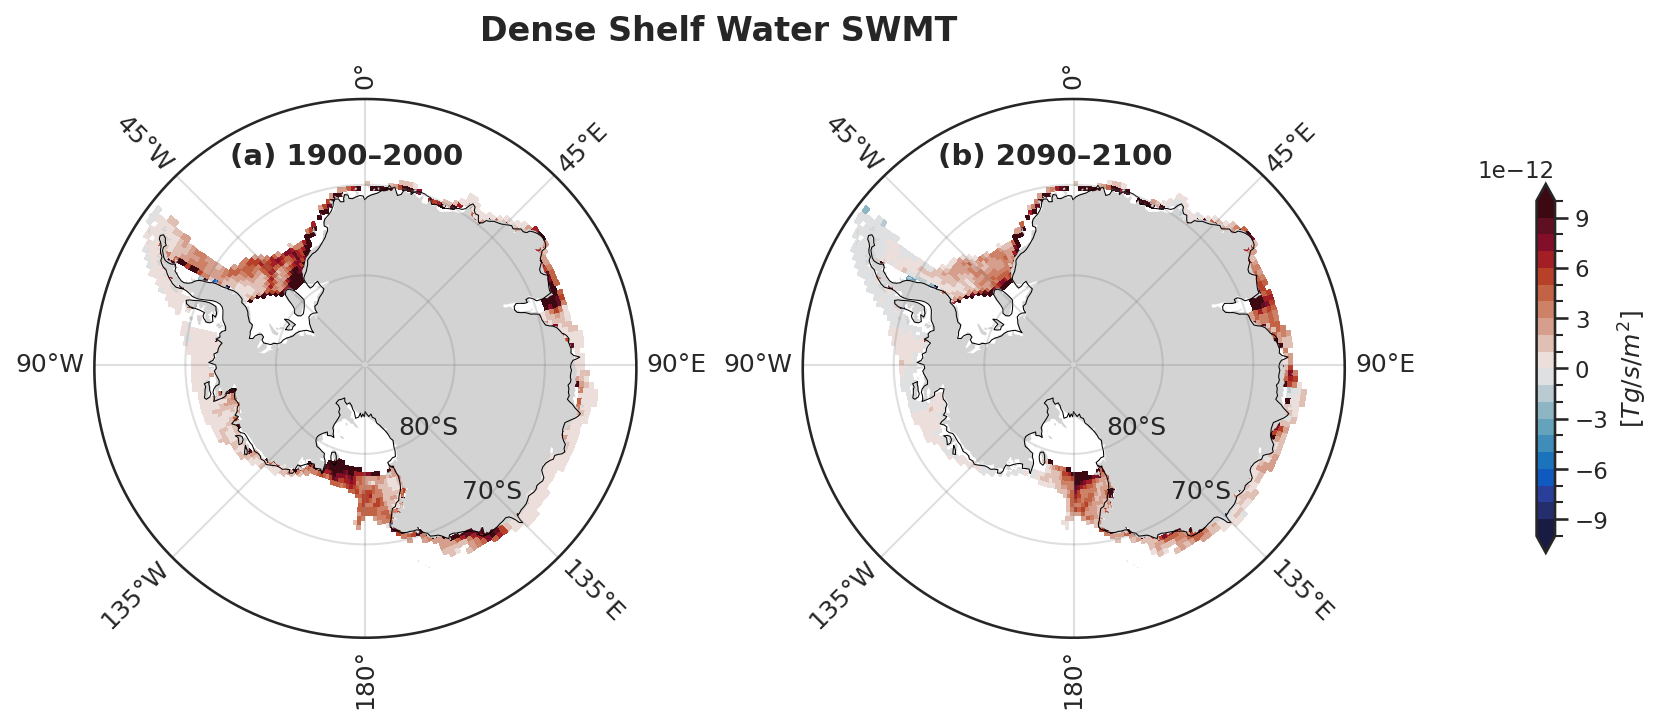

In [12]:
scale = 1
density_title = f""
cmap = cmo.balance; plt.get_cmap('Spectral_r')
boundaries = 1e-12 * np.arange(-10, 10 + 0.1,1)
boundaries[np.abs(boundaries) < 1e-16]  = 0
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

times_list = [daterange2tuple(reference_period), daterange2tuple(pert_period)]
nt = len(times_list)

fig, ax = plt.subplots(
    1, nt, figsize=(11, 5),
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
    constrained_layout=True
)

for a in ax:
    a.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

panel_letters = ["(a) 1900–2000", "(b) 2090–2100"]

cm = None
for i, times in enumerate(times_list):
    var_plot = (mean_swmt['-'.join(list(map(str, times)))]["SWMT"] * mass_flux_units_conversion) * scale
    cm = plot_antarctic(var_plot, ax[i], cmap=cmap, norm=norm, mask_threshold=1e-50)

    ax[i].text(
        0.25, 0.92, panel_letters[i],
        transform=ax[i].transAxes, ha="left", va="top",
        fontsize=14, fontweight="bold"
    )

fig.suptitle("Dense Shelf Water SWMT", fontsize=16, fontweight="bold", verticalalignment = "center", x = 0.43, y = 0.95)

cbar = fig.colorbar(cm, ax=ax, shrink=0.5, pad=0.05, extend="both")
cbar.set_label(r"[" + mass_flux_units + r"]")

fig.savefig("plots/ASC_SWMT_Spatial.png", dpi=250, bbox_inches="tight")


In [13]:
ds_diff_decomp = get_variable_spatial_decompose(mean_swmt, var = "SWMT") 
ds_ref_sum = toTg * get_variable_spatial_sum_reference(mean_swmt, var = "SWMT") 
ds_pert_sum =  toTg * get_variable_spatial_sum_pert(mean_swmt, var = "SWMT") 

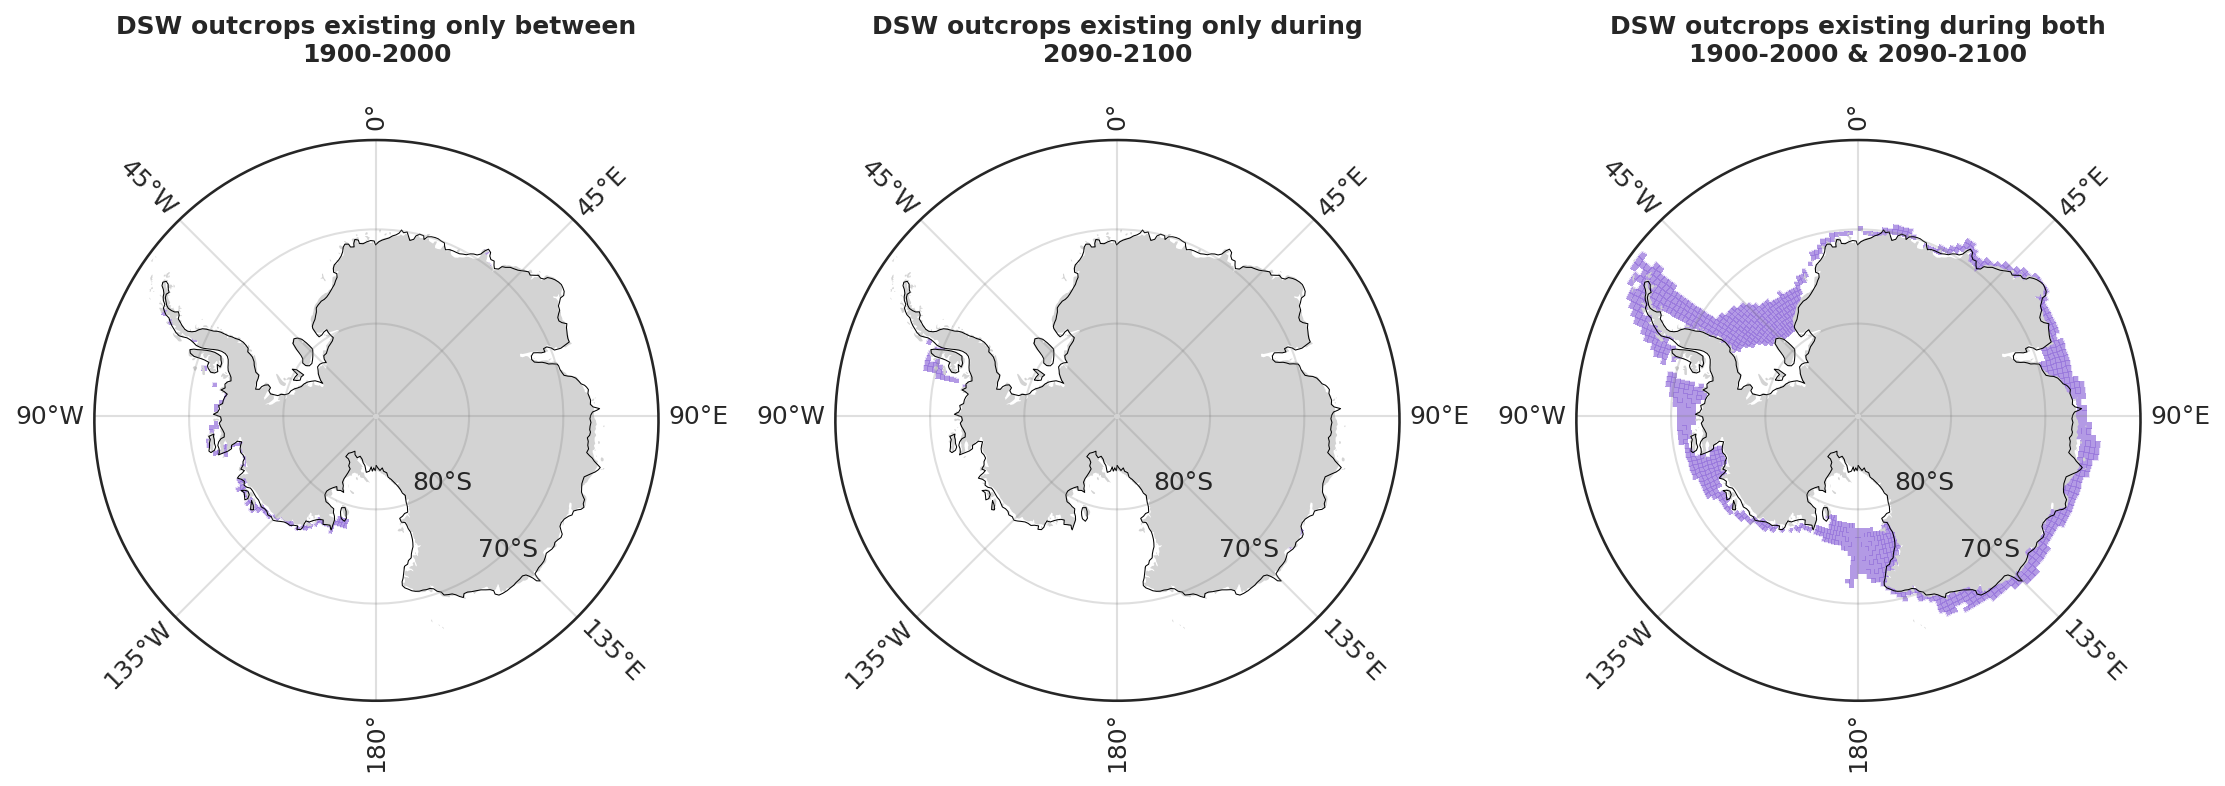

In [14]:
base = ListedColormap(['white','mediumpurple'])
colors = base(np.linspace(0, 1, base.N))
colors[:, -1] = 0.7        # set all alphas to
cmap = ListedColormap(colors)

regions = ["D_f_minus_g", "D_g_minus_f", "D_intersect"]
nr = len(regions)

fig, ax = plt.subplots(1, nr, figsize = (15, 5),
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})
[a.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()) for a in ax.flatten()]

for (i, region) in enumerate(regions):
    cm = plot_antarctic(1.0 * ds_diff_decomp[region], ax[i], 
                        cmap = cmap, norm = None, mask_threshold = -np.inf)
        


ax[0].set_title("DSW outcrops existing only between\n" + '-'.join(list(map(str, times_list[0]))) + "\n" + density_title, 
             fontweight = "bold", fontsize = 12, ha='center')

ax[1].set_title("DSW outcrops existing only during\n" + '-'.join(list(map(str, times_list[1]))) + "\n" + density_title, 
             fontweight = "bold", fontsize = 12, ha='center')


ax[2].set_title("DSW outcrops existing during both\n" + '-'.join(list(map(str, times_list[0]))) + " & " + '-'.join(list(map(str, times_list[1]))) + "\n" +  density_title, 
             fontweight = "bold", fontsize = 12, ha='center')

fig.tight_layout()

fig.savefig("plots/ASC_SWMT_Spatial_Differences.png", dpi = 250, bbox_inches = "tight")

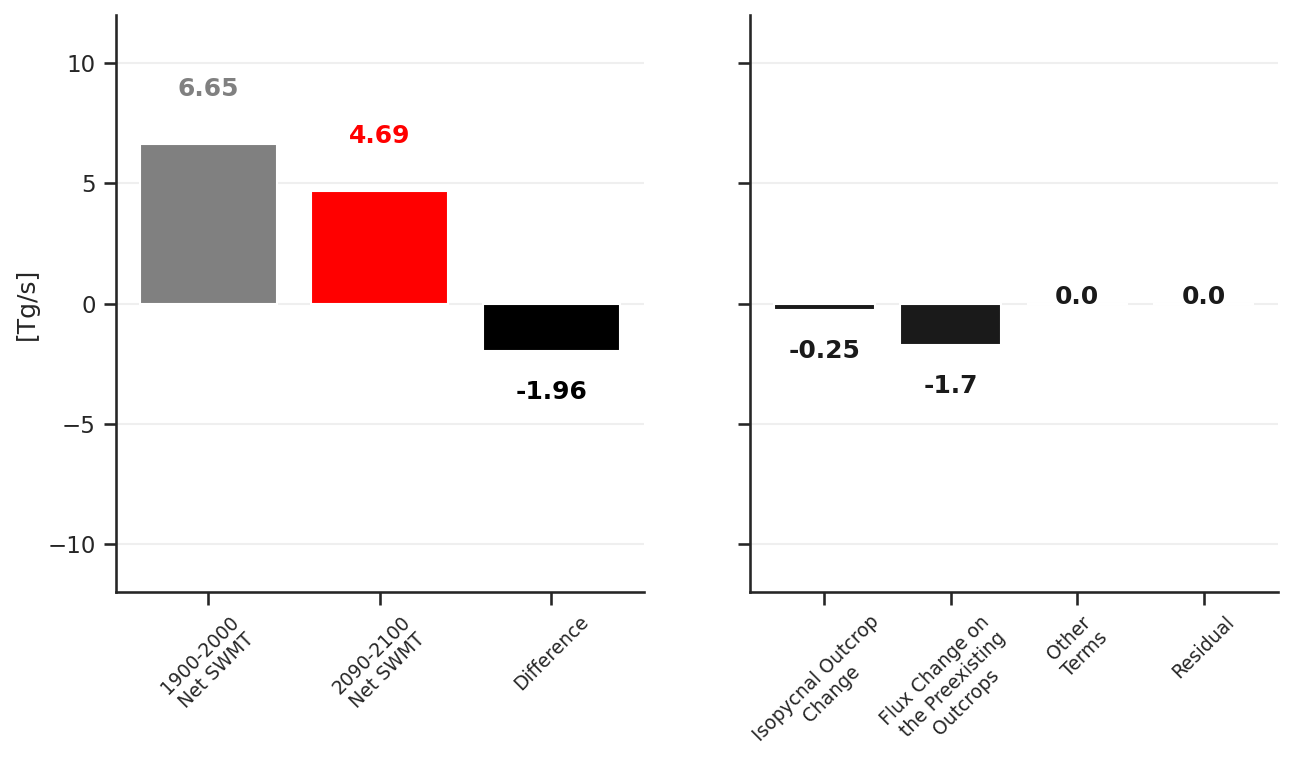

In [15]:
outcrop_shift = toTg * ds_diff_decomp["domain_shift"]
flux_change_on_preexist_outcrop = toTg * ds_diff_decomp["integrand_change"]
true_diff = toTg * ds_diff_decomp["true_total"]
residual = true_diff - (toTg *  ds_diff_decomp["reconstructed_total"])
other_terms = (true_diff - residual) - (outcrop_shift + flux_change_on_preexist_outcrop)

residual = np.round(residual, 2) + 0.0
other_terms = np.round(other_terms, 2) + 0.0


fig, ax = plt.subplots(1, 2, figsize = (10, 5), sharey = True)

lab_to_data = {
    reference_period + "\nNet SWMT": ds_ref_sum,
    pert_period + "\nNet SWMT":  ds_pert_sum,
    "Difference": true_diff,
}

labs = [k for k in lab_to_data.keys()]
bars = ax[0].bar(labs, [lab_to_data[k].values for k in labs], color = ["grey", "red", "black"])
add_bar_numbers(bars, ax[0])
ax[0].tick_params(axis='x', labelrotation=45, labelright=False)
ax[0].set_ylabel("[Tg/s]")
lab_to_data = {
    "Isopycnal Outcrop\nChange": outcrop_shift,
    "Flux Change on\n the Preexisting\nOutcrops":  flux_change_on_preexist_outcrop,
    "Other\nTerms":  other_terms,
    "Residual":  residual,

}

labs = [k for k in lab_to_data.keys()]
bars= ax[1].bar(labs, [lab_to_data[k].values for k in labs], color = "k")
add_bar_numbers(bars, ax[1])
ax[1].tick_params(axis='x', labelrotation=45, labelright=False)
for a in ax: 
    a.set_ylim(-12, 12)
    a.grid(alpha = 0.3)
    a.xaxis.grid(False)
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(axis="x", labelsize=9)  # change fontsize of xticklabels

fig.savefig("plots/DSW_SWMT_Spatial_Budget.png", dpi = 250, bbox_inches = "tight")

In [16]:
SWMT_var_to_label = {
    # heat budget
    "SWMT":             "net surface transformation",

    "SWMT_heat":             "heat",
    "SWMT_heat_latent":      "latent heat flux",
    "SWMT_heat_frazil":      "frazil",
    "SWMT_heat_longwave":    "longwave",
    "SWMT_heat_shortwave":   "shortwave heat flux",
    "SWMT_heat_mass_transfer":"mass transfer",
    "SWMT_heat_sensible":    "sensible heat flux",
    "SWMT_salt_residual":    "salt residual",
    "SWMT_residual":    "residual",

    # salt budget
    "SWMT_salt":             "salt",
    "SWMT_salt_evaporation": "evap",
    "SWMT_salt_precipitation":"precip",
    "SWMT_salt_rivers":      "rivers",
    "SWMT_salt_icebergs":    "icebergs",
    "SWMT_salt_basal_salt":  "basal salt",
    "SWMT_salt_sea_ice":     "sea ice freeze/melt flux",
    "SWMT_heat_residual":    "heat residual",
    "SWMT_salt_precip_minus_evaporation": "precip/evap"
}

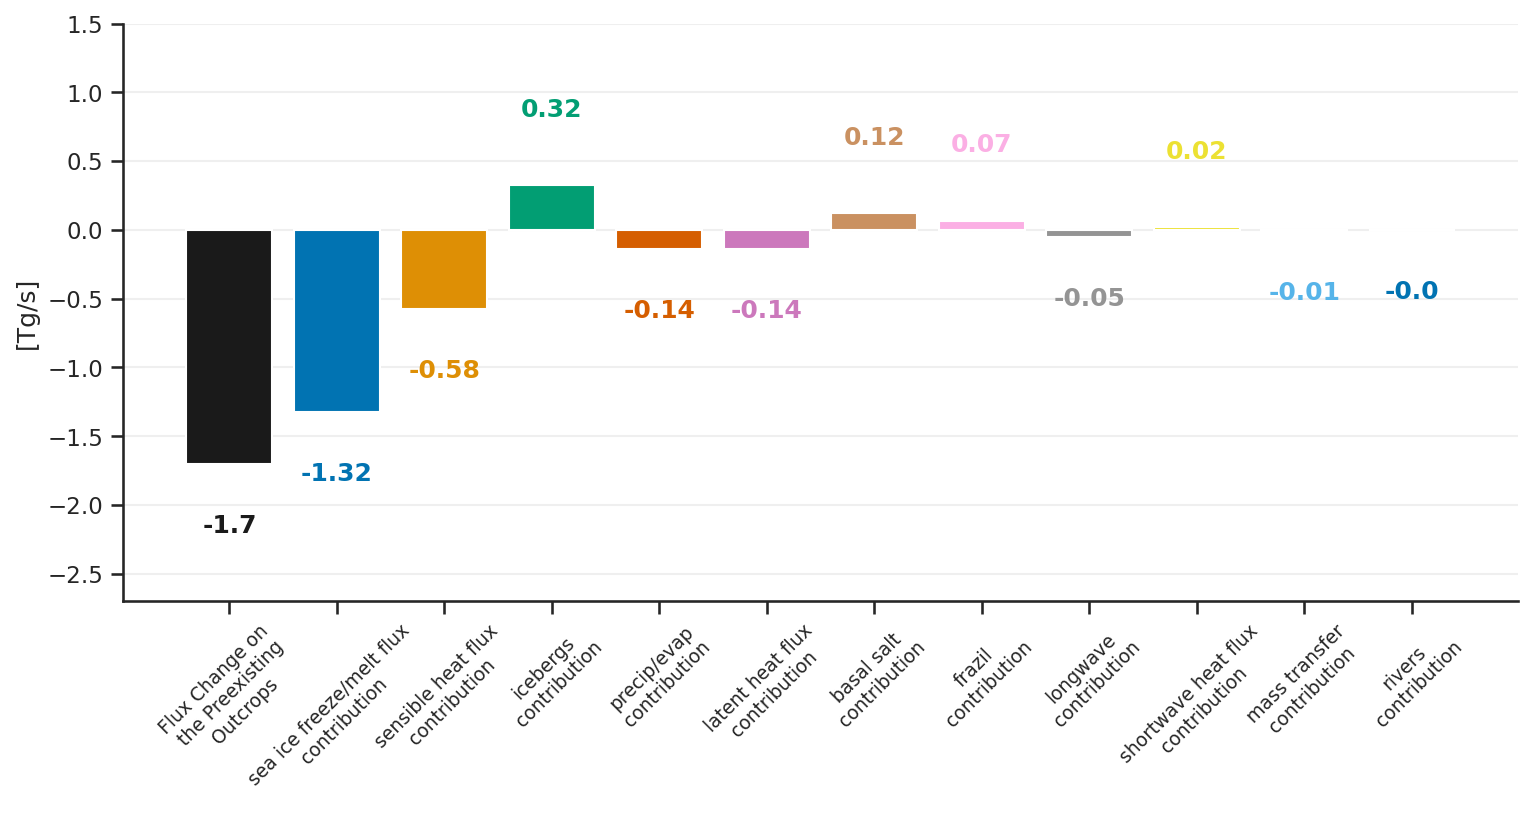

In [17]:
exclude_vars = {"boundary_fluxes_heat", "SWMT", "SWMT_salt_approx", "SWMT_heat_approx", "SWMT_heat", "SWMT_salt", "SWMT_heat_residual", "SWMT_salt_residual", "SWMT_residual"}
decomp_vars = sorted(list(set(ds_sfc_SWMT.data_vars) - exclude_vars))

# decomp_vars = ["SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave"]
decomp_labels = [SWMT_var_to_label[var] + "\ncontribution" for var in decomp_vars]
decomp_integrand_change = [toTg * get_variable_integrand_change(mean_swmt, var = var).values for var in decomp_vars]

decomp_vars = np.array(decomp_vars)[np.argsort(np.abs(np.array(decomp_integrand_change)))[::-1].tolist()]
decomp_labels = [SWMT_var_to_label[var] + "\ncontribution" for var in decomp_vars]
decomp_integrand_change = [toTg * get_variable_integrand_change(mean_swmt, var = var).values for var in decomp_vars]

# decomp_integrand_change += [toTg * get_variable_integrand_change(mean_swmt, var = "SWMT").values - np.sum(decomp_integrand_change)]
# decomp_labels += ["Other Terms"]

decomp_integrand_change = [flux_change_on_preexist_outcrop] + decomp_integrand_change
decomp_labels = ["Flux Change on\n the Preexisting\nOutcrops"] + decomp_labels
colors= ["k"] + sns.color_palette("colorblind", len(decomp_integrand_change)-1)

fig, ax = plt.subplots(figsize = (12, 5))
bars = ax.bar(decomp_labels, decomp_integrand_change, align='center', color = colors)
ax.tick_params(axis='x', labelrotation=45, labelright=False)

ax.set_ylim(-2.7, 1.5)
ax.set_ylabel("[Tg/s]")
ax.grid(alpha = 0.3)
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=9)  # change fontsize of xticklabels

add_bar_numbers(bars, ax, text_height_factor = 0.5)
fig.savefig("plots/DSW_SWMT_FluxChange_Full_Budget.png", dpi = 250, bbox_inches = "tight")

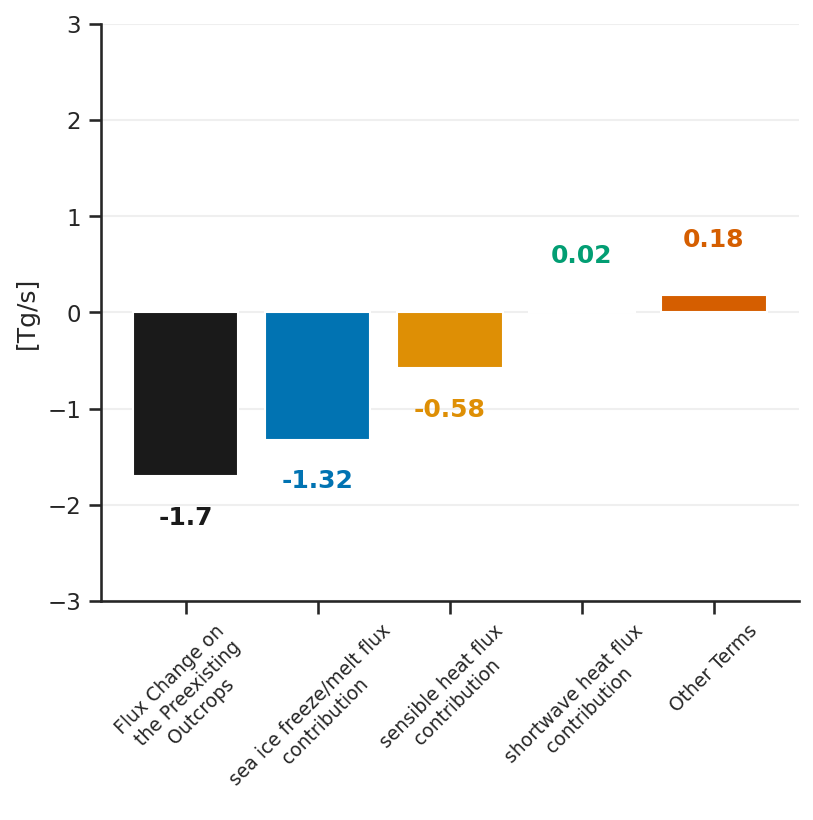

In [18]:
exclude_vars = {"boundary_fluxes_heat", "SWMT", "SWMT_salt_approx", "SWMT_heat_approx", "SWMT_heat", "SWMT_salt", "SWMT_heat_residual", "SWMT_salt_residual"}
decomp_vars = sorted(list(set(ds_sfc_SWMT.data_vars) - exclude_vars))

decomp_vars = ["SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave"]
decomp_labels = [SWMT_var_to_label[var] + "\ncontribution" for var in decomp_vars]
decomp_integrand_change = [toTg * get_variable_integrand_change(mean_swmt, var = var).values for var in decomp_vars]

decomp_integrand_change += [toTg * get_variable_integrand_change(mean_swmt, var = "SWMT").values - np.sum(decomp_integrand_change)]
decomp_labels += ["Other Terms"]

decomp_integrand_change = [flux_change_on_preexist_outcrop] + decomp_integrand_change
decomp_labels = ["Flux Change on\n the Preexisting\nOutcrops"] + decomp_labels
colors= ["k"] + sns.color_palette("colorblind", len(decomp_integrand_change)-1)

fig, ax = plt.subplots(figsize = (6, 5))
bars = ax.bar(decomp_labels, decomp_integrand_change, align='center', color = colors)
ax.tick_params(axis='x', labelrotation=45, labelright=False)

ax.set_ylim(-3, 3)
ax.set_ylabel("[Tg/s]")
ax.grid(alpha = 0.3)
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=9)  # change fontsize of xticklabels

add_bar_numbers(bars, ax, text_height_factor = 0.5)
fig.savefig("plots/DSW_SWMT_FluxChange_Budget.png", dpi = 250, bbox_inches = "tight")

In [21]:
ds_sfc_props = xr.open_mfdataset(datadir(f"/model/Southern_Ocean_50S_Monthly_Surface_Fluxes_And_Properties.zarr"))
# Define your custom seasons (example: tropical wet/dry seasons)
def custom_seasons(month):
    """Define custom seasons based on month"""
    if month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # May, June, July, AUgust
        return 'winter'
    else:
        return 'not_winter'

# Apply to your data
season_labels = xr.apply_ufunc(
    custom_seasons, 
    ds_sfc_props.time.dt.month,
    vectorize=True,
    dask='allowed'
)

# Add as coordinate
ds_sfc_props_with_seasons = ds_sfc_props.assign_coords(custom_season=('time', season_labels.data))

# # Group by custom season
# ds_sfc_props_seasonal_means = ds_sfc_props_with_seasons.groupby('custom_season').mean('time')

ds_sfc_props_winter_data = ds_sfc_props_with_seasons.where(ds_sfc_props_with_seasons.custom_season == 'winter', drop=True)
ds_sfc_props_winter_yearly_averages = ds_sfc_props_winter_data.groupby('time.year').mean('time').compute()

In [22]:
# ds_sfc_sigma_geq = ds_sfc_props_winter_yearly_averages.sel(exp = "forced")
ds_sfc_props_mod = 1 * get_sigma2_at_surface(ds_sfc_props_winter_yearly_averages, keep_vars = False).where(ds_sfc_props_winter_yearly_averages.wet > 0.0)
ds_sfc_props_mod["beta"] = gsw.beta(ds_sfc_props_mod.sa, ds_sfc_props_mod.ct, 0.0)
ds_sfc_props_mod["alpha"] = gsw.alpha(ds_sfc_props_mod.sa, ds_sfc_props_mod.ct, 0.0)

ds_sfc_sigma_geq = 1 * ds_sfc_props_mod
# ds_sfc_sigma_geq_thermo = get_sigma2_at_surface(ds_sfc_sigma_geq, keep_vars = False)

In [23]:
sum_horizontal = lambda ds: ds.sum(["xh", "yh"], skipna = True)
mean_horizontal = lambda ds: ds.mean(["xh", "yh"], skipna = True)

def forcing_at_swmt_maximum(ds, mask):
    nt = len(ds.year)
    exp = ds.exp
    sigma_targets = ds_maximum_sbf_and_psi.max_surface_boundary_flux_density.sel(exp = exp )
    ds_var = ds
    area = ds_var.areacello.where(ds_var.wet > 0.0)

    wet_mask = mask
    weights = (area * wet_mask).where(wet_mask > 0.0)
    
    test_arr = []
    for i in range(nt):
        tmp = ds_var.isel(year = i).sum("sigma2_l")
        # tmp = ds_var.sel(sigma2_l = sigma_targets.values[i]).isel(year = i)
        # tmp = ds_var.sel(sigma2_l = slice(sigma_targets.values[i], None)).isel(year = i).sum("sigma2_l")

        nan_mask = ~np.isnan(tmp)
        weighted_mask = weights * nan_mask
        tmp_weighted = (tmp * weighted_mask)

        avg_var = sum_horizontal(tmp_weighted.where(weighted_mask > 0)) / sum_horizontal(weighted_mask.where(weighted_mask > 0))
        # avg_var = mean_horizontal(tmp.where(weighted_mask > 0)) 
        test_arr += [avg_var.compute()]

    return xr.concat(test_arr, dim = "year").sortby("year").compute()

-115.14241472677558
-110.32976604212949


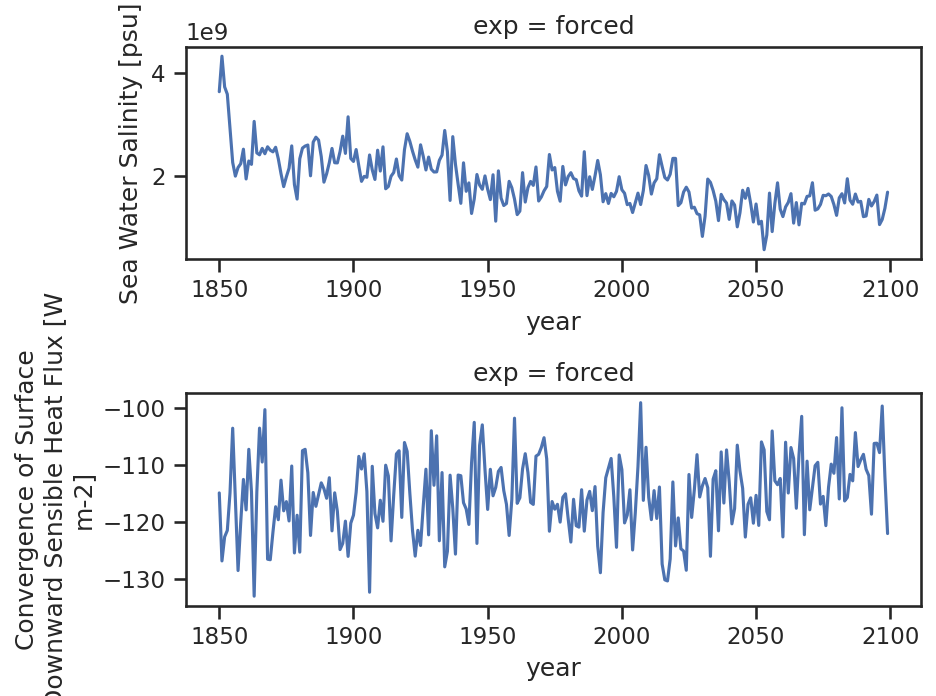

In [24]:
exp = "forced"
sigma_targets = ds_maximum_sbf_and_psi.max_surface_boundary_flux_density.sel(exp = exp ).values

tmp = ([ds_SWMT["SWMT_heat_sensible"].sel(exp = exp).sel(sigma2_l_target = sigma_targets[i]).isel(year = i) for i in range(len(sigma_targets))])
tmp = xr.concat(tmp, dim = "year")

fig, ax = plt.subplots(2, 1)
tmp.plot(ax = ax[0])

tmp = forcing_at_swmt_maximum((ds_sfc_sigma_geq["hfsso"]).sel(exp = "forced"), ds_diff_decomp["D_intersect"])
tmp.plot(ax = ax[1])
fig.tight_layout()
print(tmp.sel(year = slice(1900, 2000)).mean("year").values)

print(tmp.sel(year = slice(2090, 2100)).mean("year").values)

-0.00015998069135696711
-0.0001071637806663187


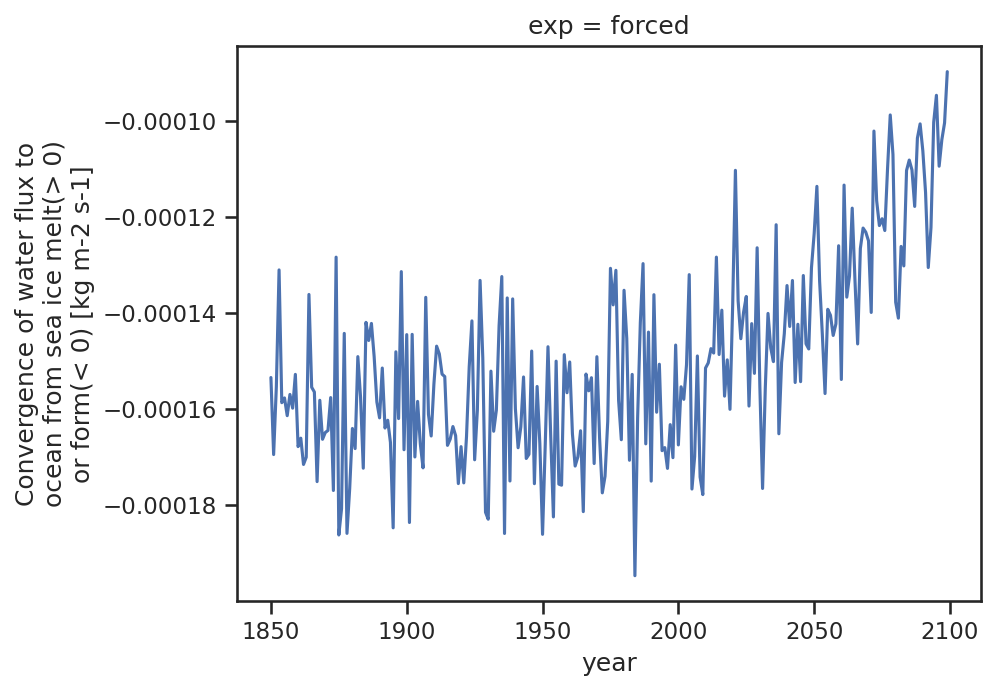

In [25]:
tmp = forcing_at_swmt_maximum((ds_sfc_sigma_geq["fsitherm"]).sel(exp = "forced"), ds_diff_decomp["D_intersect"])
tmp.plot()
fig.tight_layout()
print(tmp.sel(year = slice(1900, 2000)).mean("year").values)
print(tmp.sel(year = slice(2090, 2100)).mean("year").values)

In [26]:
def area_weighted_average(ds, mask):
    weights = (ds.areacello).where((ds.wet > 0) * (mask > 0) * (~np.isnan(ds))) #maybe don't need * ds.wet
    weighted_ds = (ds * weights).sum(["xh", "yh"], skipna = True) / weights.sum(["xh", "yh"], skipna = True)
    return weighted_ds
def area_weighted_sum(ds, mask):
    weights = (ds.areacello).where((ds.wet > 0) * (mask > 0))
    weighted_ds = (ds * weights).sum(["xh", "yh"], skipna = True)
    return weighted_ds

In [27]:
average_period = lambda ds, period_slice: ds.sel(year = period_slice).mean("year")
get_baselines = lambda ds, var: average_period(ds[var], slice(reference_period[0], reference_period[1]))
get_anomaly = lambda ds, var: average_period(ds[var], slice(pert_period[0], pert_period[1])) - ds[f"{var}_baseline"]
get_anomaly_ts = lambda ds, var: ds[var] - ds[f"{var}_baseline"]


ds_sigma_sfc_decomp = ds_sfc_sigma_geq[["rho2", "ct", "sa"]].sel(exp = "forced")
ds_sigma_sfc_decomp["rho2_baseline"] = get_baselines(ds_sigma_sfc_decomp, "rho2")
ds_sigma_sfc_decomp["ct_baseline"] = get_baselines(ds_sigma_sfc_decomp, "ct")
ds_sigma_sfc_decomp["sa_baseline"] = get_baselines(ds_sigma_sfc_decomp, "sa")


p_ref = 2000 #2000 dbar reference pressure 

# Calculate thermal expansion coefficient alpha (1/K) at reference pressure
ds_sigma_sfc_decomp['alpha_baseline'] = xr.apply_ufunc(
    gsw.alpha, ds_sigma_sfc_decomp["sa_baseline"], ds_sigma_sfc_decomp["ct_baseline"], p_ref, dask="parallelized"
)

# Calculate the haline contraction coefficient beta (kg/g) at reference pressure
ds_sigma_sfc_decomp['beta_baseline'] = xr.apply_ufunc(
    gsw.beta, ds_sigma_sfc_decomp["sa_baseline"], ds_sigma_sfc_decomp["ct_baseline"], p_ref, dask="parallelized"
)


ds_sigma_sfc_decomp["rho2_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "rho2")
ds_sigma_sfc_decomp["ct_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "ct")
ds_sigma_sfc_decomp["sa_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "sa")

# rho0 = ds_sigma_sfc_decomp["rho2_baseline"] + 1000  #could eb comething else? 
rho0 = 1035
ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"] = -rho0 * ds_sigma_sfc_decomp['alpha_baseline'] * ds_sigma_sfc_decomp["ct_anomaly"]
ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"] =  rho0 * ds_sigma_sfc_decomp['beta_baseline']  * ds_sigma_sfc_decomp["sa_anomaly"]

ds_sigma_sfc_decomp["rho2_anomaly_recon"] = ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"] + ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"]

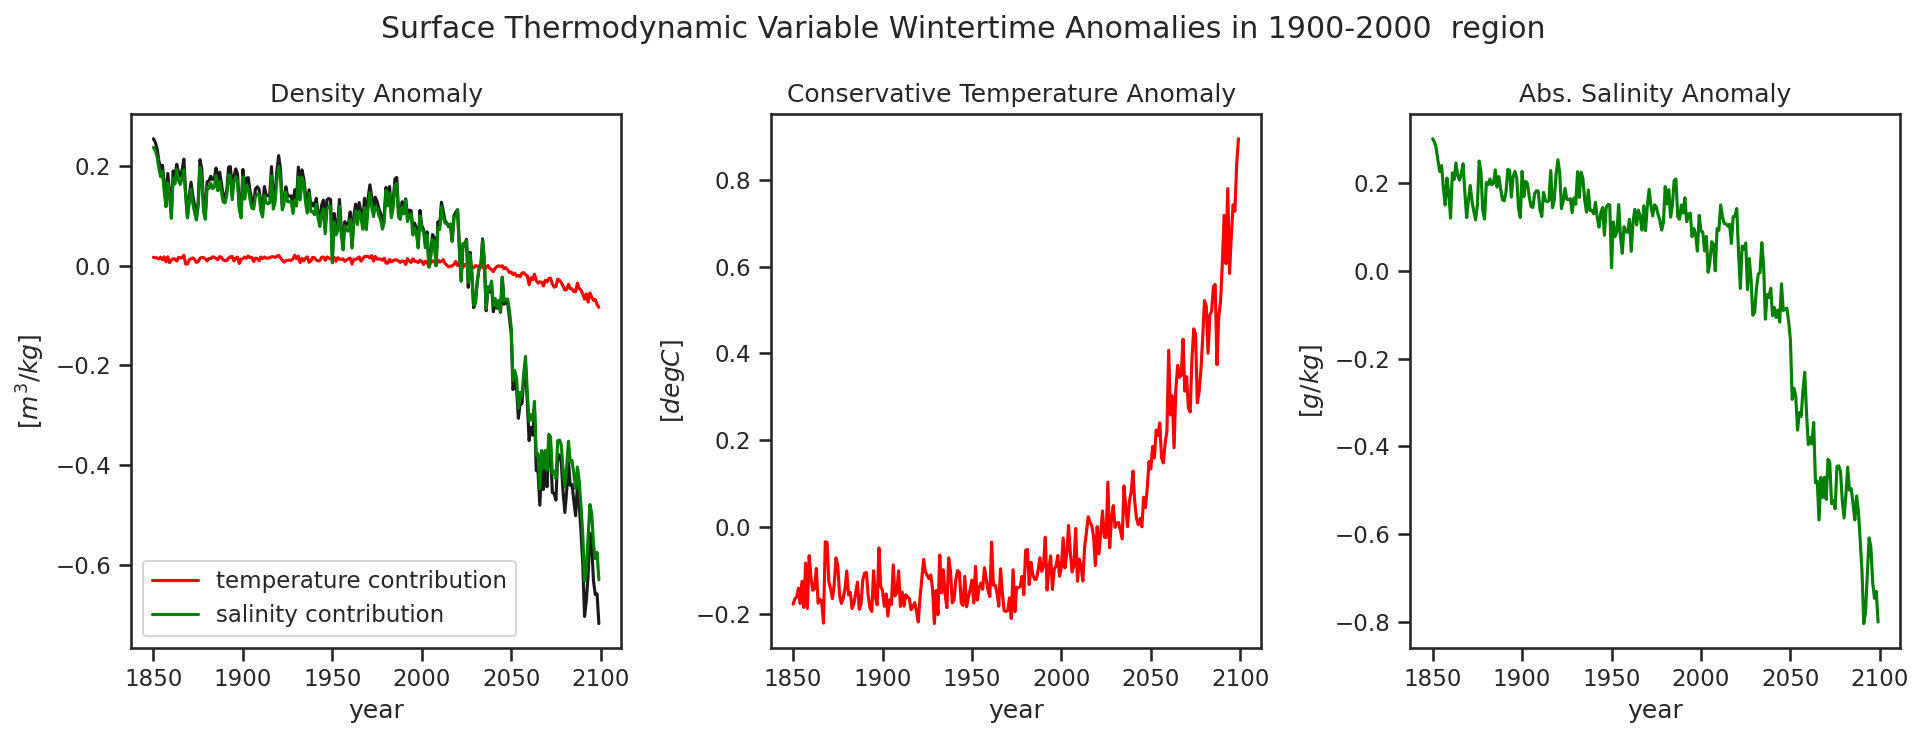

In [28]:
region_of_interest = ds_diff_decomp["D_f"]
dens_region = density_title.replace('(', '').replace(')', '').replace('\\mathbf', '')

fig, axes = plt.subplots(1, 3, figsize = (13, 5))
temp_color = "red"
sal_color = "green"
ax = axes[0]
area_weighted_average(ds_sigma_sfc_decomp["rho2_anomaly"], region_of_interest).plot(ax=ax, c= "k")

ct_contrib = ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"]# + ds_sigma_sfc_decomp["rho2_baseline"]
area_weighted_average(ct_contrib, region_of_interest).plot(ax=ax, label= "temperature contribution", c = temp_color)

sa_contrib = ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"]# + ds_sigma_sfc_decomp["rho2_baseline"]

area_weighted_average(sa_contrib, region_of_interest).plot(ax=ax, label= "salinity contribution", c = sal_color)
ax.legend()
ax.set_title(f"Density Anomaly")
ax.set_ylabel(r"$[m^3/kg]$")

ax = axes[1]
# plot temperature
temp_line = area_weighted_average(ds_sigma_sfc_decomp["ct_anomaly"], region_of_interest).plot(ax=ax, color=temp_color)
# label and color the left y‑axis for temperature
ax.set_title("Conservative Temperature Anomaly ")
ax.set_ylabel(r"$[deg C]$")

# twin for salinity
axt = axes[2]
salt_line = area_weighted_average(ds_sigma_sfc_decomp["sa_anomaly"], region_of_interest).plot(ax=axt, color=sal_color)
# label and color the right y‑axis for salinity
axt.set_title("Abs. Salinity Anomaly")
axt.set_ylabel(r"$ [g/kg]$")

fig.suptitle(f"Surface Thermodynamic Variable Wintertime Anomalies in {reference_period} " + dens_region + " region")

fig.tight_layout()

fig.savefig("plots/Dissapearing_Outcrop_Thermodynamics.png", dpi = 250, bbox_inches = "tight")

In [29]:
ds_sfc_sigma_geq_thermo_fluxes = 1 * ds_sfc_sigma_geq[["fsitherm", "hfsso", "siconc"]].sel(exp = "forced")
for var in ["fsitherm", "hfsso", "rsdoabsorb"]:
    try:
        # ds_sfc_sigma_geq_thermo_fluxes[var] = ds_sfc_sigma_geq_thermo_fluxes[var].where(ds_sfc_sigma_geq.sigma2_l >= sigma0)
        # ds_sfc_sigma_geq_thermo_fluxes[var] = ds_sfc_sigma_geq_thermo_fluxes[var].sum("sigma2_l", skipna = True)
        # ds_sfc_sigma_geq_thermo_fluxes[var] = ds_sfc_sigma_geq_thermo_fluxes[var].where(np.abs(ds_sfc_sigma_geq_thermo_fluxes[var]) > 0.0)
        print("hello")
    except: 
        print(f"Summing {var} failed")

hello
hello
hello


In [30]:
def set_ylabel_with_sci(ax, label):
    """
    Move the scientific notation offset text from the y-axis
    into the ylabel, formatting as 10^n.
    """
    # Force tick/offset calculation
    ax.figure.canvas.draw()

    # Grab the offset string (like '1e8')
    offset = ax.yaxis.get_offset_text().get_text()
    
    # Hide the offset from the axis
    ax.yaxis.offsetText.set_visible(False)

    # Convert '1e8' -> '10^8'
    if offset.startswith("1e"):
        exp = offset.replace("1e", "")
        offset_str = r"$ \times 10^{{{}}}$".format(exp)
    else:
        offset_str = offset  # fallback in case of unusual format
    
    # Update ylabel with scaling
    if offset:
        ax.set_ylabel(f"{label} {offset_str}")
    else:
        ax.set_ylabel(label)

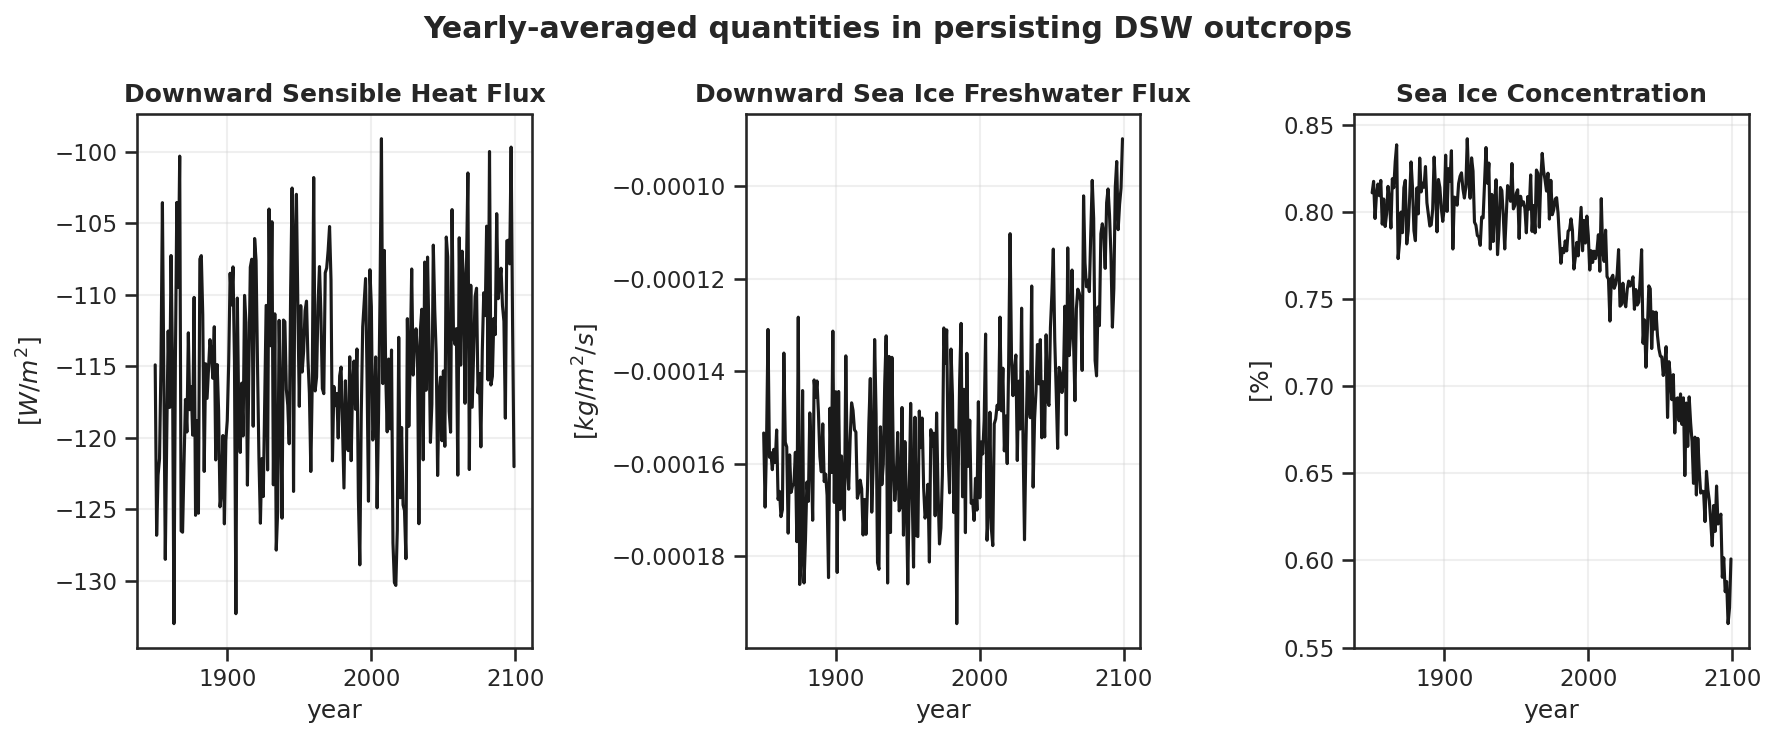

In [51]:
dens_region = density_title.replace('(', '').replace(')', '').replace('\\mathbf', '')

fig, axes = plt.subplots(1, 3, figsize = (12, 5))

ax = axes[0]
forcing_at_swmt_maximum(ds_sfc_sigma_geq_thermo_fluxes["hfsso"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title(f"Downward Sensible Heat Flux", fontweight = "bold")
set_ylabel_with_sci(ax, r"$[W/m^2]$")

ax = axes[2]
area_weighted_average(ds_sfc_sigma_geq_thermo_fluxes["siconc"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title(f"Sea Ice Concentration", fontweight = "bold")
set_ylabel_with_sci(ax, r"[$\%$]")

ax = axes[1]
forcing_at_swmt_maximum(ds_sfc_sigma_geq_thermo_fluxes["fsitherm"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title(f"Downward Sea Ice Freshwater Flux", fontweight = "bold")
set_ylabel_with_sci(ax, r"$[kg/m^2/s]$")

fig.suptitle(f"Yearly-averaged quantities in persisting DSW outcrops", fontweight = "bold")
fig.tight_layout()
[a.grid(alpha = 0.3) for a in axes]
fig.savefig("plots/Remaining_Outcrop_Fluxes.png", dpi = 150, bbox_inches = "tight")
#potential explanation for downward sensible heat fluxes: cabbeling. alpha must be negative zero in order for cooling to cause a decrease in density 

/tmp/ipykernel_18695/2565194680.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(decomp_labels, fontdict=font_props)


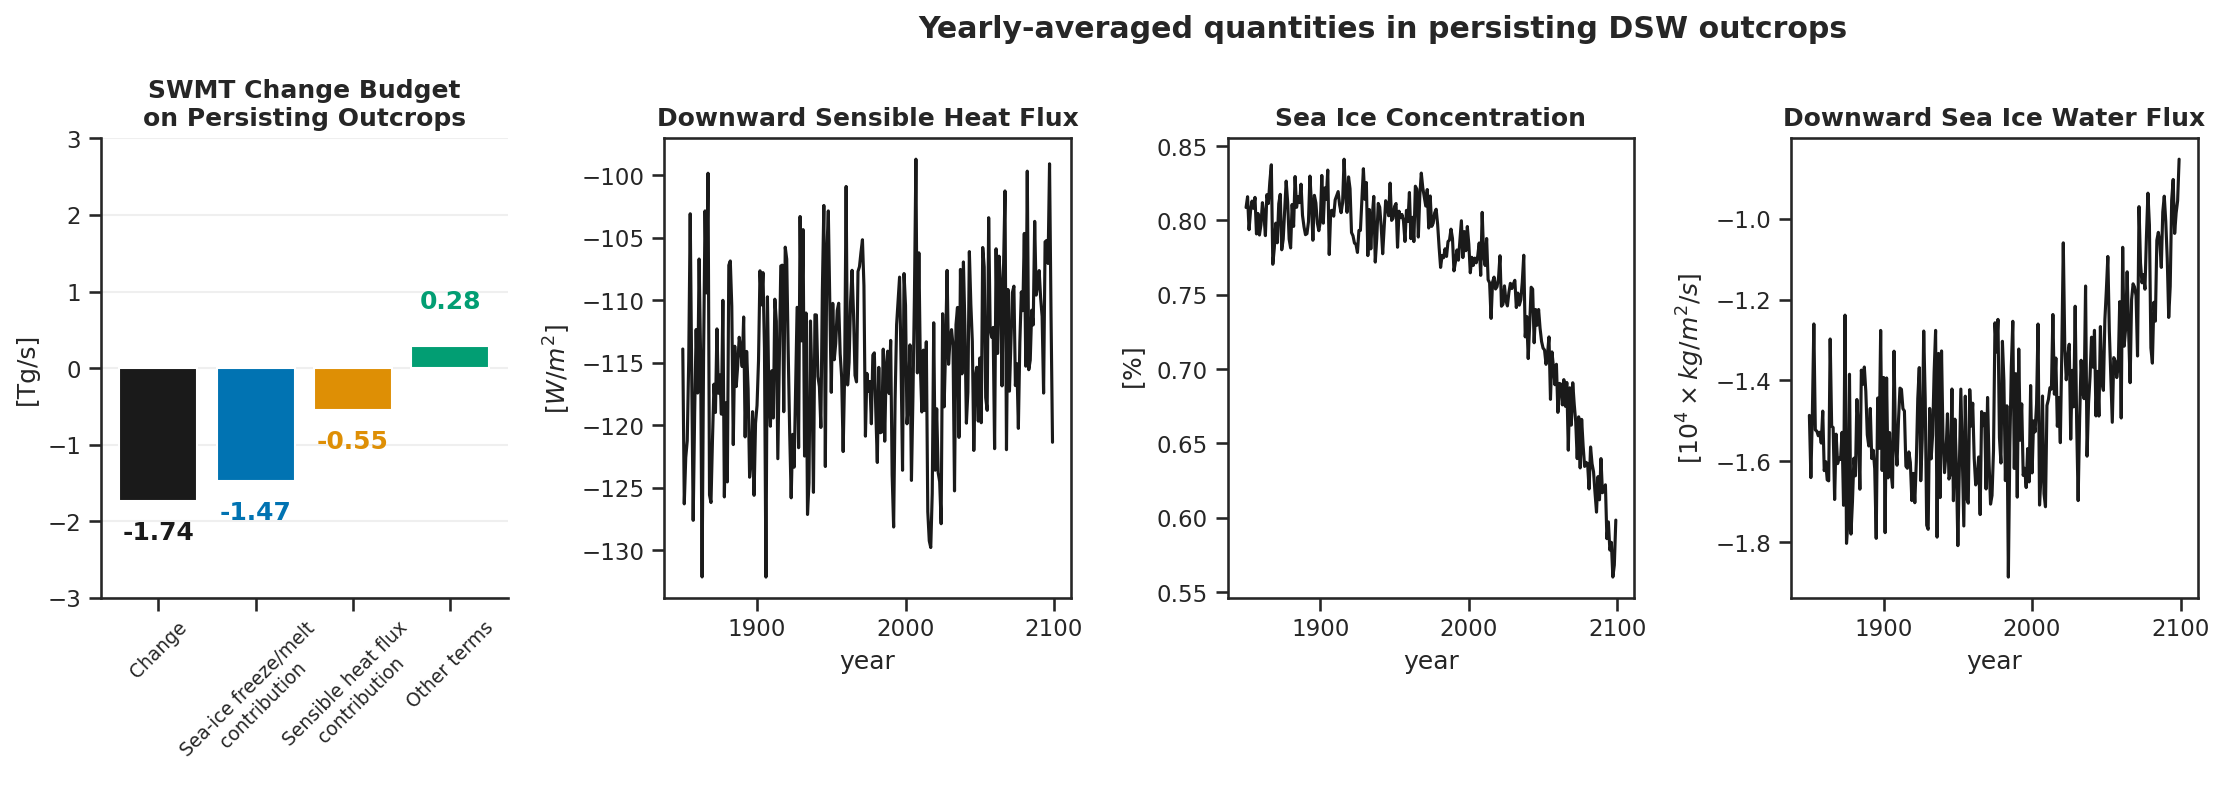

In [75]:
dens_region = density_title.replace('(', '').replace(')', '').replace('\\mathbf', '')

exclude_vars = {"boundary_fluxes_heat", "SWMT", "SWMT_salt_approx", "SWMT_heat_approx", "SWMT_heat", "SWMT_salt", "SWMT_heat_residual", "SWMT_salt_residual"}
decomp_vars = sorted(list(set(ds_sfc_SWMT.data_vars) - exclude_vars))

decomp_vars = ["SWMT_salt_sea_ice", "SWMT_heat_sensible"]
decomp_labels = ["Sea-ice freeze/melt\ncontribution", "Sensible heat flux\ncontribution"]
decomp_integrand_change = [toTg * get_variable_integrand_change(mean_swmt, var = var).values for var in decomp_vars]

decomp_integrand_change += [toTg * get_variable_integrand_change(mean_swmt, var = "SWMT").values - np.sum(decomp_integrand_change)]
decomp_labels += ["Other terms"]

decomp_integrand_change = [flux_change_on_preexist_outcrop] + decomp_integrand_change
decomp_labels = ["Change"] + decomp_labels
colors= ["k"] + sns.color_palette("colorblind", len(decomp_integrand_change)-1)

fig, axes = plt.subplots(1, 4, figsize = (15, 5))

ax = axes[0]
bars = ax.bar(decomp_labels, decomp_integrand_change, align='center', color = colors)
ax.tick_params(axis='x', labelrotation=45, labelright=False)

ax.set_ylim(-3, 3)
ax.set_ylabel("[Tg/s]")
ax.grid(alpha = 0.3)
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.tick_params(axis="x", labelsize=9, fontweight = "bold")  # change fontsize of xticklabels
font_props = {'weight': 'normal', 'fontsize': 9}
ax.set_xticklabels(decomp_labels, fontdict=font_props)
ax.set_title(f"SWMT Change Budget\non Persisting Outcrops", fontweight = "bold")

add_bar_numbers(bars, ax, text_height_factor = 0.5)

ax = axes[1]
forcing_at_swmt_maximum(ds_sfc_sigma_geq_thermo_fluxes["hfsso"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title(f"Downward Sensible Heat Flux", fontweight = "bold")
set_ylabel_with_sci(ax, r"$[W/m^2]$")

ax = axes[2]
area_weighted_average(ds_sfc_sigma_geq_thermo_fluxes["siconc"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title(f"Sea Ice Concentration", fontweight = "bold")
set_ylabel_with_sci(ax, r"[$\%$]")

ax = axes[3]
forcing_at_swmt_maximum(1e4 * ds_sfc_sigma_geq_thermo_fluxes["fsitherm"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title(f"Downward Sea Ice Water Flux", fontweight = "bold")
set_ylabel_with_sci(ax, r"$[10^4 \times kg/m^2/s]$")

fig.tight_layout()


fig.suptitle(f"Yearly-averaged quantities in persisting DSW outcrops", fontweight = "bold", x = 0.62, y = 1.05)

fig.savefig("plots/Remaining_Outcrop_Fluxes_and_budget.png", dpi = 250, bbox_inches = "tight")
#potential explanation for downward sensible heat fluxes: cabbeling. alpha must be negative zero in order for cooling to cause a decrease in density 